 Recharge proprement un échantillon

In [1]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1", nrows=100000)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


 Renommer les colonnes

In [2]:
df.columns = df.columns.str.replace(" ", "_")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Nettoyage

In [3]:
df = df.dropna()

df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70797 entries, 0 to 99857
Data columns (total 8 columns):
Invoice        70797 non-null object
StockCode      70797 non-null object
Description    70797 non-null object
Quantity       70797 non-null int64
InvoiceDate    70797 non-null object
Price          70797 non-null float64
Customer_ID    70797 non-null float64
Country        70797 non-null object
dtypes: float64(2), int64(1), object(5)
memory usage: 3.5+ MB


Créer la colonne chiffre d’affaires

In [4]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Premières analyses

In [5]:
total_revenue = df["TotalPrice"].sum()
total_revenue

1630006.1359998174

In [6]:
df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    1335676.736
EIRE                99674.550
Netherlands         59659.600
Germany             30147.700
Denmark             29118.160
France              22808.010
Spain               12640.460
Greece               5409.300
Belgium              5290.620
Cyprus               4383.990
Name: TotalPrice, dtype: float64

In [7]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
BLACK AND WHITE PAISLEY FLOWER MUG    25535
WHITE HANGING HEART T-LIGHT HOLDER    13740
SMALL FAIRY CAKE FRIDGE MAGNETS       12236
PACK OF 72 RETRO SPOT CAKE CASES      11814
JAZZ HEARTS MEMO PAD                  10921
JUMBO BAG RED WHITE SPOTTY             9474
ASSORTED COLOUR BIRD ORNAMENT          7469
JAZZ HEARTS MAGNETIC MEMO PAD          7058
PACK OF 12 RED SPOTTY TISSUES          7021
ASS FLORAL PRINT SCISSORS              6776
Name: Quantity, dtype: int64

Premier graphique

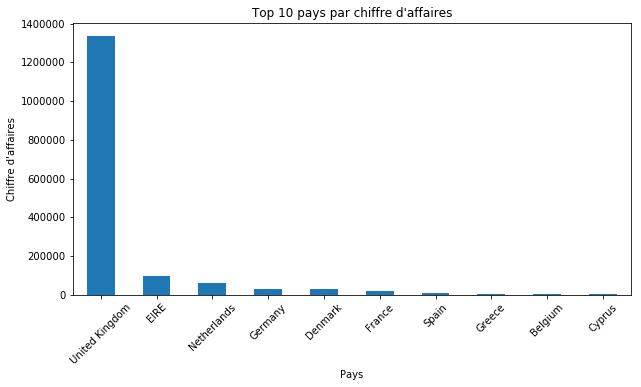

In [8]:
import matplotlib.pyplot as plt

top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 pays par chiffre d'affaires")
plt.xlabel("Pays")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70797 entries, 0 to 99857
Data columns (total 9 columns):
Invoice        70797 non-null object
StockCode      70797 non-null object
Description    70797 non-null object
Quantity       70797 non-null int64
InvoiceDate    70797 non-null object
Price          70797 non-null float64
Customer_ID    70797 non-null float64
Country        70797 non-null object
TotalPrice     70797 non-null float64
dtypes: float64(3), int64(1), object(5)
memory usage: 4.1+ MB


Chiffre d’affaires total

In [10]:
df["TotalPrice"].sum()

1630006.1359998174

### Insight

Le chiffre d’affaires total est de 1,63M.

Cela montre que le dataset est suffisamment riche pour analyser des tendances commerciales significatives.

### Analyse par pays

In [11]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

top_countries.head(10)

Country
United Kingdom    1335676.736
EIRE                99674.550
Netherlands         59659.600
Germany             30147.700
Denmark             29118.160
France              22808.010
Spain               12640.460
Greece               5409.300
Belgium              5290.620
Cyprus               4383.990
Name: TotalPrice, dtype: float64

### Insights

- Le Royaume-Uni domine largement les ventes (plus de 80% du CA)
- Les autres pays contribuent marginalement

### Interprétation :
L’activité est fortement concentrée sur un marché unique, ce qui représente un risque business.

### Produits

In [12]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_products.head(10)

Description
BLACK AND WHITE PAISLEY FLOWER MUG    25535
WHITE HANGING HEART T-LIGHT HOLDER    13740
SMALL FAIRY CAKE FRIDGE MAGNETS       12236
PACK OF 72 RETRO SPOT CAKE CASES      11814
JAZZ HEARTS MEMO PAD                  10921
JUMBO BAG RED WHITE SPOTTY             9474
ASSORTED COLOUR BIRD ORNAMENT          7469
JAZZ HEARTS MAGNETIC MEMO PAD          7058
PACK OF 12 RED SPOTTY TISSUES          7021
ASS FLORAL PRINT SCISSORS              6776
Name: Quantity, dtype: int64

### Insights

- Les produits les plus vendus sont des articles à faible coût
- La stratégie semble basée sur le volume

#### Interprétation :
Ces produits peuvent être utilisés comme produits d’appel.

### Évolution dans le temps

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_revenue = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()

monthly_revenue.head()

InvoiceDate
2009-12    686654.160
2010-01    557319.062
2010-02    386032.914
Freq: M, Name: TotalPrice, dtype: float64

### Insights

- Forte saisonnalité
- Pic en période de fin d’année

#### Interprétation :
Les ventes sont influencées par des événements commerciaux comme Noël.

Graphique

In [17]:
import matplotlib.pyplot as plt



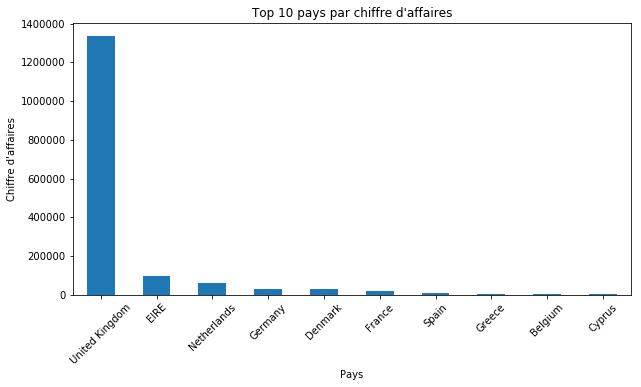

In [16]:
top_countries.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 pays par chiffre d'affaires")
plt.xlabel("Pays")
plt.ylabel("Chiffre d'affaires")

plt.xticks(rotation=45)

plt.show()